 unsupervised learning- clustering
 Bank Marketing Data Set dataset. The data is related with direct marketing campaigns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
Path='/content/drive/MyDrive/Colab Notebooks'

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sararazeen","key":"0ff39067dce207a3d8bf62adb21a1050"}'}

In [5]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d berkayalan/bank-marketing-data-set --unzip -p ./data

Dataset URL: https://www.kaggle.com/datasets/berkayalan/bank-marketing-data-set
License(s): ODbL-1.0
  0% 0.00/376k [00:00<?, ?B/s]
100% 376k/376k [00:00<00:00, 514MB/s]


In [7]:
ls ./data

bank_marketing_dataset.csv


In [8]:
!unzip ./data/bank-marketing-data-set.zip -d ./data

unzip:  cannot find or open ./data/bank-marketing-data-set.zip, ./data/bank-marketing-data-set.zip.zip or ./data/bank-marketing-data-set.zip.ZIP.


understanding the dataset

In [9]:
import pandas as pd
raw_df = pd.read_csv("./data/bank_marketing_dataset.csv")
raw_df.head(40)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [10]:
raw_df.shape

(41188, 21)

In [11]:
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


Age distribution of customers

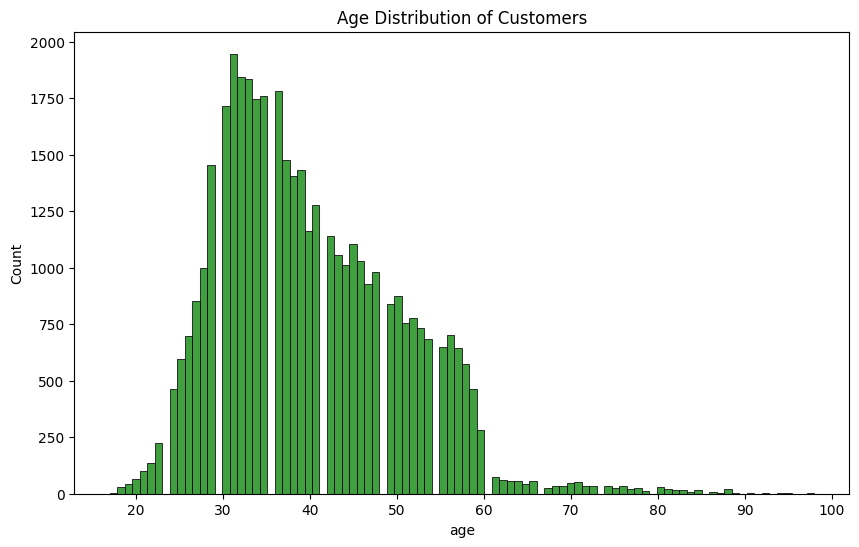

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6),dpi=100)
sns.histplot(data=raw_df,x="age",color="green")
plt.title("Age Distribution of Customers")
plt.show()

Ages & loan status of customers

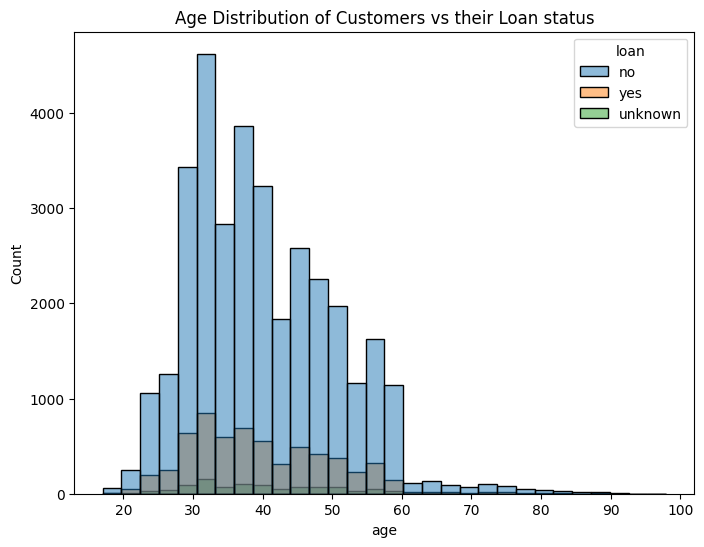

In [15]:
plt.figure(figsize=(8,6),dpi=100)
sns.histplot(data=raw_df,x="age",hue="loan",bins=30)
plt.title("Age Distribution of Customers vs their Loan status")
plt.show()

Marital status

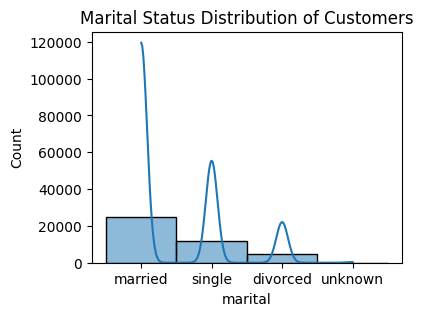

In [16]:
plt.figure(figsize=(4,3),dpi=100)
sns.histplot(data=raw_df,x="marital",kde=True)
plt.title("Marital Status Distribution of Customers")
plt.show()

pdays = number of days that passed by after the client was last contacted from a campaign.
999 = null

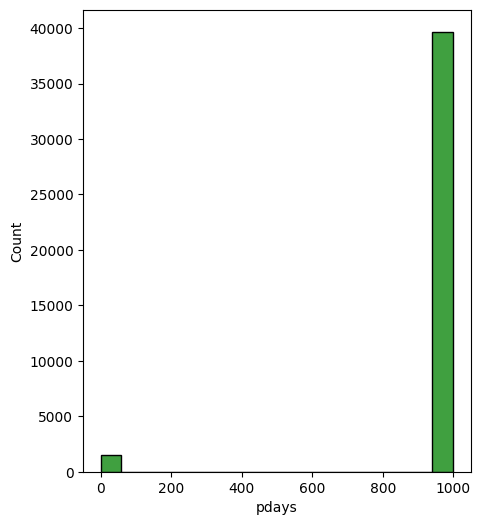

In [17]:
plt.figure(figsize=(5,6),dpi=100)
sns.histplot(data=raw_df,x="pdays",color="green")
plt.show()

In [18]:
pd.DataFrame(raw_df.pdays.value_counts()).head()

,count
pdays,
999,39673
3,439
6,412
4,118
9,64


Using above,
The clients that was not previously contacted = 39673 .
We consider only contacted clients.

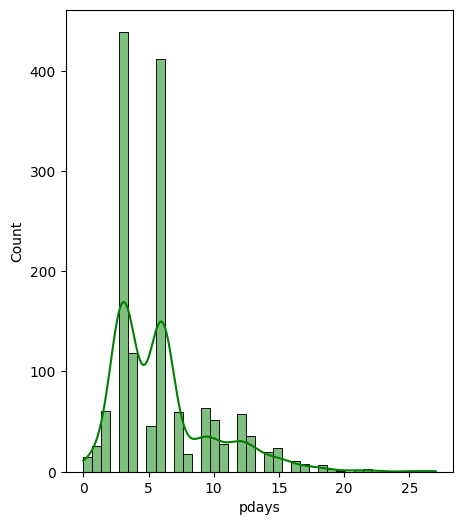

In [19]:
plt.figure(figsize=(5,6),dpi=100)
sns.histplot(data=raw_df[raw_df.pdays!=999],x="pdays",color="green",kde=True)
plt.show()

Durations based on type of contact

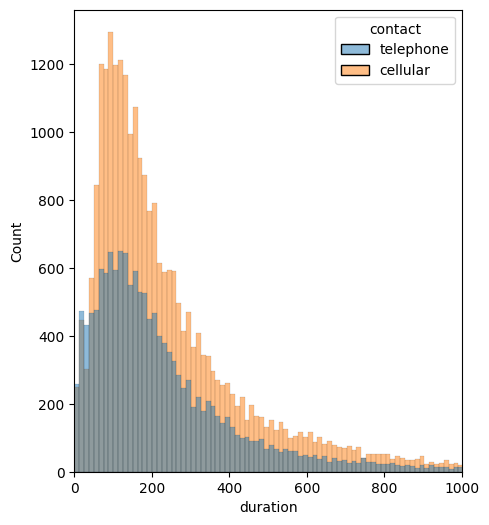

In [23]:
plt.figure(figsize=(5,6),dpi=100)
sns.histplot(data=raw_df,x="duration",hue="contact",color="blue")
plt.xlim(0,1000)
plt.show()

 loan status

Personal Loan

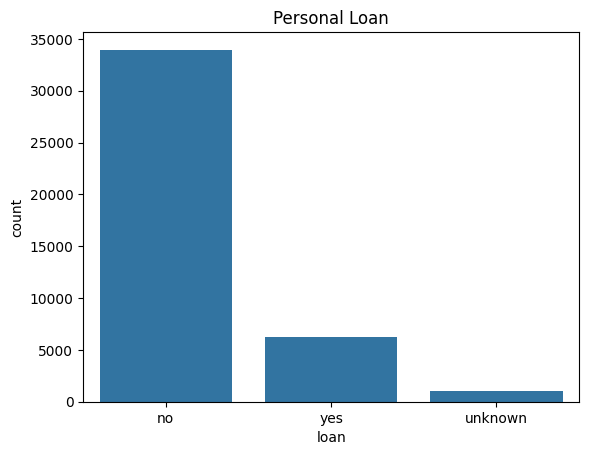

In [25]:
sns.countplot(data=raw_df,x="loan")
plt.title("Personal Loan")
plt.show()

Housing Loan

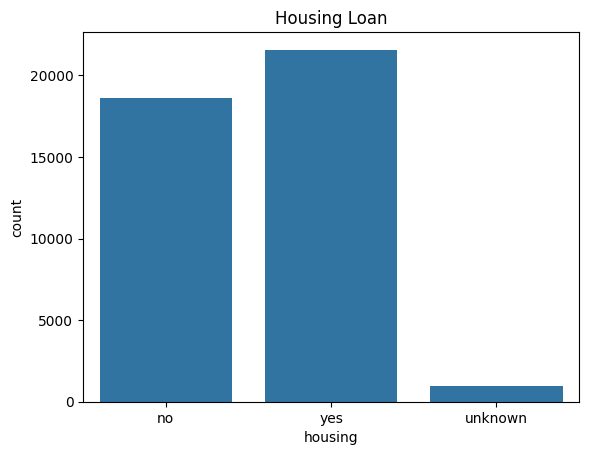

In [26]:
sns.countplot(data=raw_df,x="housing")
plt.title("Housing Loan")
plt.show()

jobs of customers

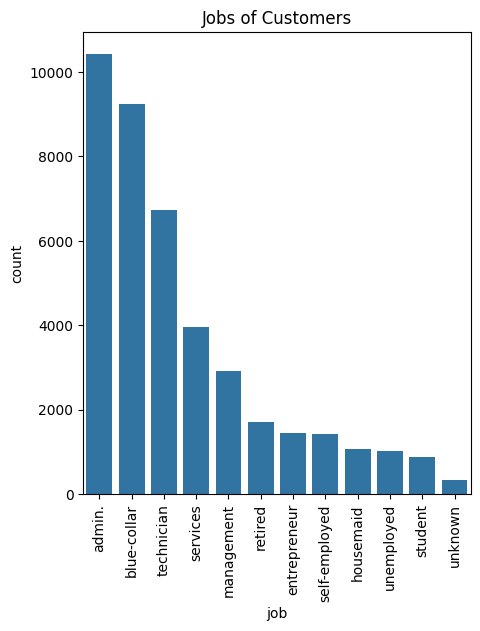

In [29]:
plt.figure(figsize=(5,6),dpi=100)
sns.countplot(data=raw_df,x="job",order=raw_df.job.value_counts().index)
plt.title("Jobs of Customers")
plt.xticks(rotation=90)
plt.show()

Education of customers

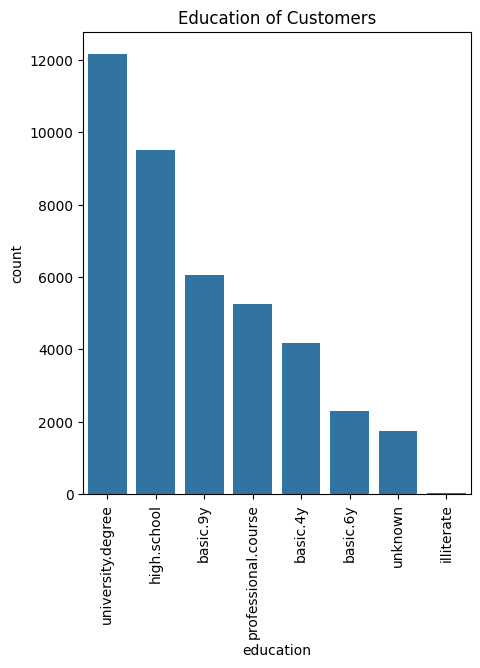

In [31]:
plt.figure(figsize=(5,6),dpi=100)
sns.countplot(data=raw_df,x="education",order=raw_df.education.value_counts().index)
plt.title("Education of Customers")
plt.xticks(rotation=90)
plt.show()

Using Clustering techniques

K-Means

 features converted to numeric format

In [35]:
raw_df.shape

(41188, 21)

In [37]:
df_dummies = pd.get_dummies(raw_df)

In [38]:
df_dummies.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False


created new column for each category of each feature

In [39]:
df_dummies.shape

(41188, 65)

apply scaling

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [43]:
df_scaled = scaler.fit_transform(df_dummies)

In [44]:
df_scaled[0]

array([ 1.53303429,  0.01047142, -0.56592197,  0.1954139 , -0.34949428,
        0.64809227,  0.72272247,  0.88644656,  0.71245988,  0.33167991,
       -0.58202282, -0.53831699, -0.19143021,  6.15277204, -0.2764353 ,
       -0.2087573 , -0.18903213, -0.3265564 , -0.1473267 , -0.44244927,
       -0.15887166, -0.08987076, -0.35509663,  0.80763764, -0.62493754,
       -0.04411455,  2.97708361, -0.24274754, -0.41474269, -0.54809999,
       -0.0209096 , -0.38191849, -0.64753149, -0.20945296,  0.51371278,
       -0.51359953, -0.00853476,  1.10081447, -0.1569334 , -1.04887691,
        0.46173139, -0.1569334 , -0.42287213, -1.31826996,  1.31826996,
       -0.26127446, -0.42007603, -0.06662113, -0.45925282, -0.38504233,
       -0.11590677,  1.41115463, -0.33253245, -0.13319736, -0.11846175,
       -0.484371  ,  1.95899952, -0.51458089, -0.49439422, -0.4960667 ,
       -0.3392905 ,  0.39770593, -0.1857    ,  0.35630932, -0.35630932])

In [46]:
from sklearn.cluster import KMeans
k_means_model = KMeans(n_clusters=2)

In [47]:
k_means_model.fit(df_scaled)

KMeans(n_clusters=2)

In [49]:
cluster_labels = k_means_model.fit_predict(df_scaled)

In [50]:
cluster_labels

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

merge cluster labels

In [51]:
df_dummies["Cluster"] = cluster_labels

In [52]:
df_dummies.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes,Cluster
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,0


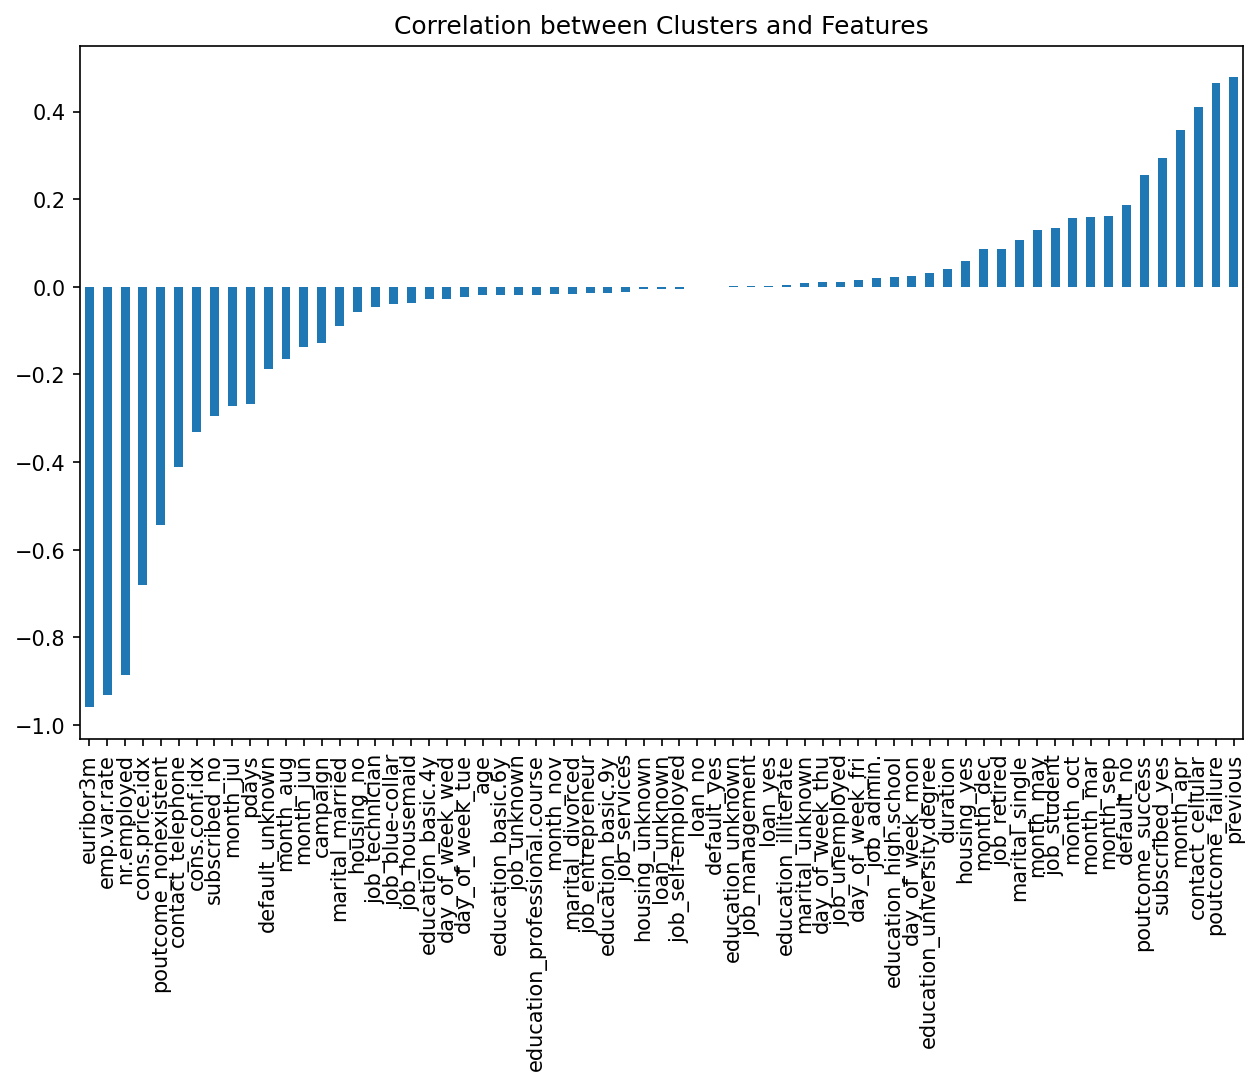

In [55]:
plt.figure(figsize=(10,6),dpi=150)
df_dummies.corr()["Cluster"].iloc[:-1].sort_values().plot(kind="bar")
plt.title("Correlation between Clusters and Features")
plt.show()